# Comptage de repetitions avec des reseaux de neurones

Ce notebook analyse une video d'exercice physique et compte automatiquement le nombre de repetitions effectuees. Il compare trois outils d'intelligence artificielle differents pour estimer les mouvements du bras : **MediaPipe**, **MoveNet** et **YOLO**.

Chaque outil detecte la position de l'epaule, du coude et du poignet frame par frame, calcule l'angle du coude, puis compte les repetitions en fonction des variations de cet angle.

## 1. Installation des librairies

On installe ici tous les outils necessaires. Cette etape n'est a faire qu'une seule fois par session.

In [1]:
!pip -q install --upgrade mediapipe tensorflow tensorflow-hub ultralytics opencv-python scipy pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 17.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

## 2. Importation des outils

On charge tous les modules Python dont on va avoir besoin tout au long du notebook.

In [2]:
import os
import time
import urllib.request
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_hub as hub

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# On essaie de charger scipy pour le lissage de signal
SCIPY_DISPONIBLE = True
try:
    from scipy.signal import savgol_filter as filtre_savgol_scipy
    from scipy.signal import find_peaks as detection_pics_scipy
except Exception as e:
    SCIPY_DISPONIBLE = False
    filtre_savgol_scipy = None
    detection_pics_scipy = None
    print(f"[WARN] SciPy indisponible, version de secours utilisee : {e}")

## 3. Chargement de la video

Importez ici votre video d'exercice. Une fois le fichier selectionne, son nom sera recupere automatiquement.

In [3]:
from google.colab import files

# Fenetre d'upload : selectionnez votre video
fichiers_uploades = files.upload()
CHEMIN_VIDEO = list(fichiers_uploades.keys())[0]

Saving biceps curls.mp4 to biceps curls.mp4


## 4. Parametres de l'analyse

Ajustez ces parametres en fonction de votre video avant de lancer l'analyse.

| Parametre | Description |
|---|---|
| `COTE_BRAS` | Bras a analyser : `"right"` (droit) ou `"left"` (gauche) |
| `NB_REPS_REEL` | Nombre reel de repetitions dans la video (pour mesurer la precision) |
| `SAUVER_VIDEOS_OVERLAY` | Sauvegarder les videos annotees (ralentit l'execution) |
| `ACTIVER_YOLO_POSE` | Activer ou non le modele YOLO |
| `FENETRE_LISSAGE` | Largeur de la fenetre de lissage du signal d'angle |
| `DISTANCE_MIN_REPS` | Nombre minimum de frames entre deux repetitions |
| `PROMINENCE_MIN_DEG` | Variation minimale en degres pour valider une repetition |

In [4]:
COTE_BRAS = "right"          # bras analyse
NB_REPS_REEL = 9             # nombre de repetitions reelles dans la video
SAUVER_VIDEOS_OVERLAY = False
ACTIVER_YOLO_POSE = True

NB_MAX_FRAMES = None         # None = toute la video
PAS_FRAMES = 1               # 1 = chaque frame, 2 = une sur deux, etc.

FENETRE_LISSAGE = 11
DISTANCE_MIN_REPS = 8
PROMINENCE_MIN_DEG = 8

CONF_MIN_MEDIAPIPE = 0.20    # seuil de confiance minimum pour MediaPipe
CONF_MIN_MOVENET = 0.20      # seuil de confiance minimum pour MoveNet
CONF_MIN_YOLO = 0.20         # seuil de confiance minimum pour YOLO

DOSSIER_SORTIE = "benchmark_outputs"
os.makedirs(DOSSIER_SORTIE, exist_ok=True)

print(f"CHEMIN_VIDEO={CHEMIN_VIDEO}")
print(f"COTE_BRAS={COTE_BRAS}, NB_REPS_REEL={NB_REPS_REEL}, ACTIVER_YOLO_POSE={ACTIVER_YOLO_POSE}")

CHEMIN_VIDEO=biceps curls.mp4
COTE_BRAS=right, NB_REPS_REEL=9, ACTIVER_YOLO_POSE=True


## 5. Lecture de la video

On lit la video frame par frame et on stocke les images en memoire pour les analyser ensuite.

In [5]:
def charger_frames_video(chemin_video, nb_max_frames=None, pas_frames=1):
    cap = cv2.VideoCapture(chemin_video)
    if not cap.isOpened():
        raise RuntimeError(f"Impossible d'ouvrir la video : {chemin_video}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 0:
        fps = 30.0  # valeur par defaut si le FPS n'est pas lisible

    frames_bgr = []
    index_frame = 0
    frames_gardees = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        # On garde seulement une frame sur "pas_frames"
        if index_frame % pas_frames == 0:
            frames_bgr.append(frame)
            frames_gardees += 1

            if nb_max_frames is not None and frames_gardees >= nb_max_frames:
                break

        index_frame += 1

    cap.release()
    fps_effectif = fps / max(1, pas_frames)

    return frames_bgr, fps_effectif


frames_bgr, fps_video = charger_frames_video(
    CHEMIN_VIDEO,
    nb_max_frames=NB_MAX_FRAMES,
    pas_frames=PAS_FRAMES
)

print(f"{len(frames_bgr)} frames chargees | FPS effectif = {fps_video:.2f}")

528 frames chargees | FPS effectif = 30.00


## 6. Fonctions utilitaires

Ces fonctions sont utilisees par tous les modeles. Elles gerent :
- le calcul de l'angle du coude a partir des coordonnees des articulations
- le lissage du signal d'angle pour reduire le bruit
- la detection des repetitions dans le signal lisse
- le dessin des annotations sur les frames

In [6]:
def indices_bras(cote_bras="right"):
    """Retourne les indices des points epaule, coude, poignet selon le cote."""
    if cote_bras.lower() == "right":
        return 12, 14, 16
    if cote_bras.lower() == "left":
        return 11, 13, 15
    raise ValueError("COTE_BRAS doit etre 'right' ou 'left'")


def angle_degres(a, b, c):
    """Calcule l'angle forme par trois points a, b, c (b est le sommet)."""
    if a is None or b is None or c is None:
        return np.nan

    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    c = np.array(c, dtype=float)

    if np.any(np.isnan(a)) or np.any(np.isnan(b)) or np.any(np.isnan(c)):
        return np.nan

    ba = a - b
    bc = c - b

    norme_ba = np.linalg.norm(ba)
    norme_bc = np.linalg.norm(bc)

    if norme_ba < 1e-6 or norme_bc < 1e-6:
        return np.nan

    # Produit scalaire normalise puis conversion en degres
    cosinus = np.dot(ba, bc) / (norme_ba * norme_bc)
    cosinus = np.clip(cosinus, -1.0, 1.0)

    return float(np.degrees(np.arccos(cosinus)))


def interpoler_signal(x, limite=20):
    """Remplace les valeurs manquantes par interpolation lineaire."""
    serie = pd.Series(x, dtype=float)
    return serie.interpolate(method="linear", limit=limite, limit_direction="both").to_numpy()


def moyenne_mobile_fallback(x, fenetre=11):
    """Lissage par moyenne glissante, utilise si scipy est absent."""
    serie = pd.Series(x, dtype=float).interpolate(limit_direction="both")
    fenetre = int(fenetre)

    if fenetre < 3:
        fenetre = 3
    if fenetre % 2 == 0:
        fenetre += 1  # la fenetre doit etre impaire

    return serie.rolling(window=fenetre, center=True, min_periods=1).mean().to_numpy()


def lisser_signal(x, fenetre=11):
    """Lisse le signal d'angle pour eliminer les oscillations parasites."""
    x = np.asarray(x, dtype=float)

    if np.sum(np.isfinite(x)) < 5:
        return x.copy()

    if SCIPY_DISPONIBLE and filtre_savgol_scipy is not None:
        fenetre = fenetre if fenetre % 2 == 1 else fenetre + 1
        fenetre = min(fenetre, len(x) if len(x) % 2 == 1 else len(x) - 1)

        if fenetre >= 5:
            try:
                # Filtre de Savitzky-Golay : lissage polynomial
                return filtre_savgol_scipy(x, window_length=fenetre, polyorder=3, mode="interp")
            except Exception:
                pass

    return moyenne_mobile_fallback(x, fenetre=fenetre)


def detection_pics_fallback(signal, distance=1, prominence=0):
    """Detecte les pics du signal sans scipy."""
    x = pd.Series(signal, dtype=float).interpolate(limit_direction="both").to_numpy()
    n = len(x)

    if n < 3:
        return np.array([], dtype=int), {"prominences": np.array([], dtype=float)}

    candidats = []
    prominences = []

    for i in range(1, n - 1):
        # Un pic est un point plus haut que ses deux voisins
        if x[i] > x[i - 1] and x[i] >= x[i + 1]:
            p = x[i] - max(min(x[i], x[i - 1]), min(x[i], x[i + 1]))
            if p >= prominence:
                candidats.append(i)
                prominences.append(p)

    if not candidats:
        return np.array([], dtype=int), {"prominences": np.array([], dtype=float)}

    candidats = np.array(candidats, dtype=int)
    prominences = np.array(prominences, dtype=float)

    # On garde les pics les plus saillants en respectant la distance minimale
    ordre = np.argsort(prominences)[::-1]
    selectionnes = []

    for idx_ordre in ordre:
        idx = candidats[idx_ordre]
        if all(abs(idx - s) >= max(1, int(distance)) for s in selectionnes):
            selectionnes.append(int(idx))

    selectionnes = np.array(sorted(selectionnes), dtype=int)
    prom_selectionnees = np.array(
        [prominences[np.where(candidats == s)[0][0]] for s in selectionnes],
        dtype=float
    )

    return selectionnes, {"prominences": prom_selectionnees}


def detection_pics_safe(signal, distance=1, prominence=0):
    """Detecte les pics en utilisant scipy si disponible, sinon la version de secours."""
    if SCIPY_DISPONIBLE and detection_pics_scipy is not None:
        try:
            return detection_pics_scipy(signal, distance=distance, prominence=prominence)
        except Exception:
            pass

    return detection_pics_fallback(signal, distance=distance, prominence=prominence)


def compter_reps_angle_coude(angle_lisse):
    """Compte les repetitions via une machine a etats haut/bas sur l'angle du coude."""
    x = np.asarray(angle_lisse, dtype=float)
    valides = np.isfinite(x)

    if valides.sum() < 8:
        return 0, np.array([], dtype=int), np.nan, np.nan, np.nan, np.nan, np.nan

    x_valide = x[valides]

    angle_min = float(np.nanmin(x_valide))
    angle_max = float(np.nanmax(x_valide))
    angle_moy = float(np.nanmean(x_valide))

    # Les seuils bas/haut definissent la zone de comptage
    seuil_bas = float(np.nanpercentile(x_valide, 30))
    seuil_haut = float(np.nanpercentile(x_valide, 70))

    if (seuil_haut - seuil_bas) < 8.0:
        # Si l'amplitude est trop faible, on recalcule les seuils
        amplitude = angle_max - angle_min
        seuil_bas = angle_min + 0.35 * amplitude
        seuil_haut = angle_min + 0.65 * amplitude

    etat = "down"
    reps = 0
    evenements = []
    ecart_min = max(4, int(DISTANCE_MIN_REPS))
    dernier_event = -10**9

    for i, angle in enumerate(x):
        if not np.isfinite(angle):
            continue

        # Transition bas -> haut : le bras descend
        if etat == "down":
            if angle <= seuil_bas:
                etat = "up"
        else:
            # Transition haut -> bas : le bras remonte, on compte une rep
            if angle >= seuil_haut:
                if (i - dernier_event) >= ecart_min:
                    reps += 1
                    evenements.append(i)
                    dernier_event = i
                etat = "down"

    return reps, np.array(evenements, dtype=int), seuil_bas, seuil_haut, angle_min, angle_max, angle_moy


def metrique_stabilite(angle_lisse):
    """Mesure la regularite du signal (ecart-type des differences successives)."""
    x = np.asarray(angle_lisse, dtype=float)
    valides = np.isfinite(x)

    if valides.sum() < 4:
        return np.nan

    return float(np.nanstd(np.diff(x[valides])))


def dessiner_overlay(frame_bgr, epaule, coude, poignet, angle=None, reps=None):
    """Dessine les articulations et l'angle sur une frame."""
    sortie = frame_bgr.copy()

    def dessiner_point(point, couleur):
        if point is None or np.any(np.isnan(point)):
            return
        cv2.circle(sortie, (int(point[0]), int(point[1])), 6, couleur, -1)

    if epaule is not None and coude is not None and not (np.any(np.isnan(epaule)) or np.any(np.isnan(coude))):
        cv2.line(sortie, (int(epaule[0]), int(epaule[1])), (int(coude[0]), int(coude[1])), (0, 255, 0), 3)

    if coude is not None and poignet is not None and not (np.any(np.isnan(coude)) or np.any(np.isnan(poignet))):
        cv2.line(sortie, (int(coude[0]), int(coude[1])), (int(poignet[0]), int(poignet[1])), (0, 255, 0), 3)

    dessiner_point(epaule, (255, 0, 0))
    dessiner_point(coude, (0, 255, 255))
    dessiner_point(poignet, (0, 0, 255))

    y = 30
    if angle is not None and np.isfinite(angle):
        cv2.putText(sortie, f"Angle: {angle:.1f}", (10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        y += 25

    if reps is not None:
        cv2.putText(sortie, f"Reps: {reps}", (10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    return sortie


def sauver_video_overlay(chemin_sortie, frames_bgr, fps):
    """Sauvegarde les frames annotees en fichier video MP4."""
    if not frames_bgr:
        return

    h, w = frames_bgr[0].shape[:2]
    writer = cv2.VideoWriter(chemin_sortie, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    for frame in frames_bgr:
        writer.write(frame)

    writer.release()


def apercu_frames(frames_bgr, titre="Apercu", n=6):
    """Affiche un apercu de n frames reparties dans la video."""
    if not frames_bgr:
        return

    indices = np.linspace(0, len(frames_bgr) - 1, min(n, len(frames_bgr))).astype(int)

    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        ax.imshow(cv2.cvtColor(frames_bgr[idx], cv2.COLOR_BGR2RGB))
        ax.set_title(f"{titre}\nframe {idx}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 7. Configuration de MediaPipe

**MediaPipe** est un outil developpe par Google qui detecte les points cles du corps humain (articulations) dans une image. On telecharge ici le modele "lite" (version legere et rapide).

In [7]:
CHEMIN_MODELE_MP = os.path.join(DOSSIER_SORTIE, "pose_landmarker_lite.task")
URL_MODELE_MP = (
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
    "pose_landmarker_lite/float16/latest/pose_landmarker_lite.task"
)

# Telechargement du modele uniquement s'il n'est pas deja present
if not os.path.exists(CHEMIN_MODELE_MP):
    urllib.request.urlretrieve(URL_MODELE_MP, CHEMIN_MODELE_MP)


def creer_pose_landmarker_mediapipe(chemin_modele):
    """Cree et configure le detecteur de pose MediaPipe."""
    options = vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=chemin_modele),
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=CONF_MIN_MEDIAPIPE,
        min_pose_presence_confidence=CONF_MIN_MEDIAPIPE,
        min_tracking_confidence=CONF_MIN_MEDIAPIPE,
        output_segmentation_masks=False,
    )
    return vision.PoseLandmarker.create_from_options(options)

## 8. Configuration de MoveNet

**MoveNet** est un autre modele de detection de pose developpe par Google, disponible en deux versions :
- **Lightning** : plus rapide, moins precis
- **Thunder** : plus lent, plus precis

In [8]:
# Indices des articulations du bras dans le format MoveNet
INDICES_BRAS_MOVENET = {
    "left": (5, 7, 9),
    "right": (6, 8, 10)
}


def charger_movenet(variant="lightning"):
    """Telecharge et charge le modele MoveNet depuis TensorFlow Hub."""
    if variant == "lightning":
        url_modele, taille_input = "https://tfhub.dev/google/movenet/singlepose/lightning/4", 192
    elif variant == "thunder":
        url_modele, taille_input = "https://tfhub.dev/google/movenet/singlepose/thunder/4", 256
    else:
        raise ValueError("variant doit etre 'lightning' ou 'thunder'")

    modele = hub.load(url_modele)
    return modele.signatures["serving_default"], taille_input


def inference_movenet(frame_rgb, fonction_movenet, taille_input):
    """Applique MoveNet sur une frame et retourne les coordonnees des 17 points du corps."""
    image = tf.image.resize_with_pad(tf.expand_dims(frame_rgb, axis=0), taille_input, taille_input)
    image = tf.cast(image, dtype=tf.int32)
    sortie = fonction_movenet(image)
    return sortie["output_0"].numpy()[0, 0, :, :]  # tableau (17, 3) : y, x, confiance

## 9. Configuration de YOLO Pose

**YOLO** (You Only Look Once) est un modele de detection d'objets tres populaire. La version **YOLOv8n-pose** est sa variante legere specialisee dans la detection de pose humaine.

In [9]:
YOLO_DISPONIBLE = False

try:
    if ACTIVER_YOLO_POSE:
        from ultralytics import YOLO
        YOLO_DISPONIBLE = True
except Exception as e:
    print(f"[WARN] YOLO indisponible : {e}")

# Indices des articulations du bras dans le format YOLO
INDICES_BRAS_YOLO = {
    "left": (5, 7, 9),
    "right": (6, 8, 10)
}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 10. Structure de stockage des resultats

On definit ici un objet qui va centraliser tous les resultats d'un modele : angles detectes, nombre de repetitions, performances, etc.

In [10]:
@dataclass
class ResultatModele:
    """Contient tous les resultats et metriques d'un modele pour une video."""
    nom_modele: str
    angle_brut: np.ndarray
    angle_lisse: np.ndarray
    evenements_reps: np.ndarray
    nb_reps: int
    seuil_bas: float
    seuil_haut: float
    angle_min: float
    angle_max: float
    angle_moyen: float
    ratio_detection_valide: float
    confiance_moyenne: float
    fps_estime: float
    temps_moyen_frame_ms: float
    stabilite: float
    chemin_overlay: str
    points_epaule: list
    points_coude: list
    points_poignet: list


def finaliser_resultat_modele(
    nom_modele,
    angle_brut,
    conf,
    temps_frames_ms,
    overlays,
    fps,
    sauver_overlay=False,
    points_epaule=None,
    points_coude=None,
    points_poignet=None
):
    """Calcule toutes les metriques et construit l'objet ResultatModele."""
    # Interpolation puis lissage du signal brut
    angle_interpole = interpoler_signal(angle_brut, limite=20)
    angle_lisse = lisser_signal(angle_interpole, fenetre=FENETRE_LISSAGE)

    nb_reps, evenements_reps, seuil_bas, seuil_haut, angle_min, angle_max, angle_moyen = \
        compter_reps_angle_coude(angle_lisse)

    print(
        f"[{nom_modele}] min={angle_min:.1f}, max={angle_max:.1f}, mean={angle_moyen:.1f}, "
        f"low_th={seuil_bas:.1f}, high_th={seuil_haut:.1f}, reps={nb_reps}"
    )

    ratio_detection_valide = float(np.mean(np.isfinite(angle_brut))) if len(angle_brut) else np.nan
    confiance_moyenne = float(np.nanmean(conf)) if np.sum(np.isfinite(conf)) else np.nan
    temps_moyen_frame_ms = float(np.nanmean(temps_frames_ms)) if len(temps_frames_ms) else np.nan
    fps_estime = float(1000.0 / temps_moyen_frame_ms) if temps_moyen_frame_ms and temps_moyen_frame_ms > 0 else np.nan
    stabilite = metrique_stabilite(angle_lisse)

    chemin_overlay = ""
    if sauver_overlay and overlays:
        nom_safe = nom_modele.lower().replace(" ", "_").replace("(", "").replace(")", "")
        chemin_overlay = os.path.join(DOSSIER_SORTIE, f"overlay_{nom_safe}.mp4")
        sauver_video_overlay(chemin_overlay, overlays, fps)

    return ResultatModele(
        nom_modele=nom_modele,
        angle_brut=np.array(angle_brut, dtype=float),
        angle_lisse=np.array(angle_lisse, dtype=float),
        evenements_reps=np.array(evenements_reps, dtype=int),
        nb_reps=int(nb_reps),
        seuil_bas=float(seuil_bas) if np.isfinite(seuil_bas) else np.nan,
        seuil_haut=float(seuil_haut) if np.isfinite(seuil_haut) else np.nan,
        angle_min=float(angle_min) if np.isfinite(angle_min) else np.nan,
        angle_max=float(angle_max) if np.isfinite(angle_max) else np.nan,
        angle_moyen=float(angle_moyen) if np.isfinite(angle_moyen) else np.nan,
        ratio_detection_valide=ratio_detection_valide,
        confiance_moyenne=confiance_moyenne,
        fps_estime=fps_estime,
        temps_moyen_frame_ms=temps_moyen_frame_ms,
        stabilite=stabilite,
        chemin_overlay=chemin_overlay,
        points_epaule=points_epaule if points_epaule is not None else [],
        points_coude=points_coude if points_coude is not None else [],
        points_poignet=points_poignet if points_poignet is not None else [],
    )

## 11. Pipelines d'analyse par modele

Chaque fonction ci-dessous applique un modele sur toutes les frames de la video : elle detecte les articulations, calcule l'angle du coude et mesure les performances.

In [11]:
def executer_mediapipe(frames_bgr, fps, cote_bras="right", sauver_overlay=False):
    """Lance l'analyse MediaPipe sur toutes les frames."""
    idx_epaule, idx_coude, idx_poignet = indices_bras(cote_bras)

    angles_bruts = []
    confs = []
    temps_frames = []
    overlays = []
    points_epaule = []
    points_coude = []
    points_poignet = []

    with creer_pose_landmarker_mediapipe(CHEMIN_MODELE_MP) as landmarker:
        for i, frame_bgr in enumerate(frames_bgr):
            t0 = time.perf_counter()

            rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            image_mp = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            timestamp_ms = int((i / fps) * 1000)  # timestamp en millisecondes

            res = landmarker.detect_for_video(image_mp, timestamp_ms)

            epaule = coude = poignet = None
            conf_i = np.nan

            if res.pose_landmarks and len(res.pose_landmarks) > 0:
                lm = res.pose_landmarks[0]
                s, e, w = lm[idx_epaule], lm[idx_coude], lm[idx_poignet]

                # Conversion des coordonnees normalisees en pixels
                epaule = np.array([s.x * frame_bgr.shape[1], s.y * frame_bgr.shape[0]], dtype=float)
                coude = np.array([e.x * frame_bgr.shape[1], e.y * frame_bgr.shape[0]], dtype=float)
                poignet = np.array([w.x * frame_bgr.shape[1], w.y * frame_bgr.shape[0]], dtype=float)

                conf_i = float(np.nanmean([
                    getattr(s, "visibility", np.nan),
                    getattr(e, "visibility", np.nan),
                    getattr(w, "visibility", np.nan),
                ]))

            points_epaule.append(epaule)
            points_coude.append(coude)
            points_poignet.append(poignet)

            angle = angle_degres(epaule, coude, poignet)
            angles_bruts.append(angle)
            confs.append(conf_i)

            if sauver_overlay:
                overlays.append(dessiner_overlay(frame_bgr, epaule, coude, poignet, angle=angle, reps=None))

            temps_frames.append((time.perf_counter() - t0) * 1000.0)

    return finaliser_resultat_modele(
        nom_modele="MediaPipe PoseLandmarker",
        angle_brut=angles_bruts,
        conf=np.array(confs, dtype=float),
        temps_frames_ms=np.array(temps_frames, dtype=float),
        overlays=overlays,
        fps=fps,
        sauver_overlay=sauver_overlay,
        points_epaule=points_epaule,
        points_coude=points_coude,
        points_poignet=points_poignet,
    )


def executer_movenet(frames_bgr, fps, variant="lightning", cote_bras="right", sauver_overlay=False):
    """Lance l'analyse MoveNet (lightning ou thunder) sur toutes les frames."""
    fonction_movenet, taille_input = charger_movenet(variant)
    idx_epaule, idx_coude, idx_poignet = INDICES_BRAS_MOVENET[cote_bras.lower()]

    angles_bruts = []
    confs = []
    temps_frames = []
    overlays = []
    points_epaule = []
    points_coude = []
    points_poignet = []

    for frame_bgr in frames_bgr:
        t0 = time.perf_counter()

        rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        keypoints = inference_movenet(rgb, fonction_movenet, taille_input)

        h, w = frame_bgr.shape[:2]
        ks, ke, kw = keypoints[idx_epaule], keypoints[idx_coude], keypoints[idx_poignet]
        conf_i = float(np.mean([ks[2], ke[2], kw[2]]))

        epaule = coude = poignet = None
        # On utilise les points seulement si la confiance est suffisante
        if ks[2] >= CONF_MIN_MOVENET and ke[2] >= CONF_MIN_MOVENET and kw[2] >= CONF_MIN_MOVENET:
            epaule = np.array([ks[1] * w, ks[0] * h], dtype=float)
            coude = np.array([ke[1] * w, ke[0] * h], dtype=float)
            poignet = np.array([kw[1] * w, kw[0] * h], dtype=float)

        points_epaule.append(epaule)
        points_coude.append(coude)
        points_poignet.append(poignet)

        angle = angle_degres(epaule, coude, poignet)
        angles_bruts.append(angle)
        confs.append(conf_i)

        if sauver_overlay:
            overlays.append(dessiner_overlay(frame_bgr, epaule, coude, poignet, angle=angle, reps=None))

        temps_frames.append((time.perf_counter() - t0) * 1000.0)

    return finaliser_resultat_modele(
        nom_modele=f"MoveNet {variant.title()}",
        angle_brut=angles_bruts,
        conf=np.array(confs, dtype=float),
        temps_frames_ms=np.array(temps_frames, dtype=float),
        overlays=overlays,
        fps=fps,
        sauver_overlay=sauver_overlay,
        points_epaule=points_epaule,
        points_coude=points_coude,
        points_poignet=points_poignet,
    )


def executer_yolo_pose(frames_bgr, fps, cote_bras="right", sauver_overlay=False):
    """Lance l'analyse YOLO Pose sur toutes les frames."""
    if not ACTIVER_YOLO_POSE or not YOLO_DISPONIBLE:
        return None

    try:
        modele = YOLO("yolov8n-pose.pt")  # telechargement automatique si absent
    except Exception as e:
        print(f"[WARN] Chargement YOLO echoue : {e}")
        return None

    idx_epaule, idx_coude, idx_poignet = INDICES_BRAS_YOLO[cote_bras.lower()]

    angles_bruts = []
    confs = []
    temps_frames = []
    overlays = []
    points_epaule = []
    points_coude = []
    points_poignet = []

    for frame_bgr in frames_bgr:
        t0 = time.perf_counter()

        epaule = coude = poignet = None
        conf_i = np.nan

        try:
            pred = modele.predict(frame_bgr, verbose=False)

            if pred and len(pred) > 0 and pred[0].keypoints is not None and len(pred[0].keypoints.data) > 0:
                k = pred[0].keypoints.data[0].cpu().numpy()
                ks, ke, kw = k[idx_epaule], k[idx_coude], k[idx_poignet]

                conf_i = float(np.mean([ks[2], ke[2], kw[2]]))

                if ks[2] >= CONF_MIN_YOLO and ke[2] >= CONF_MIN_YOLO and kw[2] >= CONF_MIN_YOLO:
                    epaule = np.array([ks[0], ks[1]], dtype=float)
                    coude = np.array([ke[0], ke[1]], dtype=float)
                    poignet = np.array([kw[0], kw[1]], dtype=float)
        except Exception:
            pass  # on ignore les frames ou la detection echoue

        points_epaule.append(epaule)
        points_coude.append(coude)
        points_poignet.append(poignet)

        angle = angle_degres(epaule, coude, poignet)
        angles_bruts.append(angle)
        confs.append(conf_i)

        if sauver_overlay:
            overlays.append(dessiner_overlay(frame_bgr, epaule, coude, poignet, angle=angle, reps=None))

        temps_frames.append((time.perf_counter() - t0) * 1000.0)

    return finaliser_resultat_modele(
        nom_modele="YOLOv8n Pose",
        angle_brut=angles_bruts,
        conf=np.array(confs, dtype=float),
        temps_frames_ms=np.array(temps_frames, dtype=float),
        overlays=overlays,
        fps=fps,
        sauver_overlay=sauver_overlay,
        points_epaule=points_epaule,
        points_coude=points_coude,
        points_poignet=points_poignet,
    )

## 12. Execution des modeles

On lance ici les quatre analyses en sequence. Chaque modele parcourt toutes les frames de la video et produit un objet de resultats.

In [12]:
resultats = []

print("Analyse avec MediaPipe...")
resultats.append(
    executer_mediapipe(frames_bgr, fps_video, cote_bras=COTE_BRAS, sauver_overlay=SAUVER_VIDEOS_OVERLAY)
)

print("Analyse avec MoveNet Lightning...")
resultats.append(
    executer_movenet(frames_bgr, fps_video, variant="lightning", cote_bras=COTE_BRAS, sauver_overlay=SAUVER_VIDEOS_OVERLAY)
)

print("Analyse avec MoveNet Thunder...")
resultats.append(
    executer_movenet(frames_bgr, fps_video, variant="thunder", cote_bras=COTE_BRAS, sauver_overlay=SAUVER_VIDEOS_OVERLAY)
)

if ACTIVER_YOLO_POSE:
    print("Analyse avec YOLO Pose...")
    resultat_yolo = executer_yolo_pose(frames_bgr, fps_video, cote_bras=COTE_BRAS, sauver_overlay=SAUVER_VIDEOS_OVERLAY)

    if resultat_yolo is not None:
        resultats.append(resultat_yolo)
    else:
        print("YOLO Pose ignore.")

Analyse avec MediaPipe...
[MediaPipe PoseLandmarker] min=43.5, max=179.9, mean=136.8, low_th=120.3, high_th=167.3, reps=9
Analyse avec MoveNet Lightning...
[MoveNet Lightning] min=73.8, max=176.0, mean=126.0, low_th=108.2, high_th=140.7, reps=10
Analyse avec MoveNet Thunder...
[MoveNet Thunder] min=74.8, max=189.0, mean=141.4, low_th=127.5, high_th=162.0, reps=12
Analyse avec YOLO Pose...
[YOLOv8n Pose] min=23.3, max=183.6, mean=145.8, low_th=154.5, high_th=169.4, reps=9


## 12b. Comparaison visuelle des articulations detectees

On affiche ici, pour plusieurs frames reparties dans la video, comment chaque modele a positionne les points epaule, coude et poignet. Cela permet de voir a l'oeil nu ou chaque modele place les articulations.

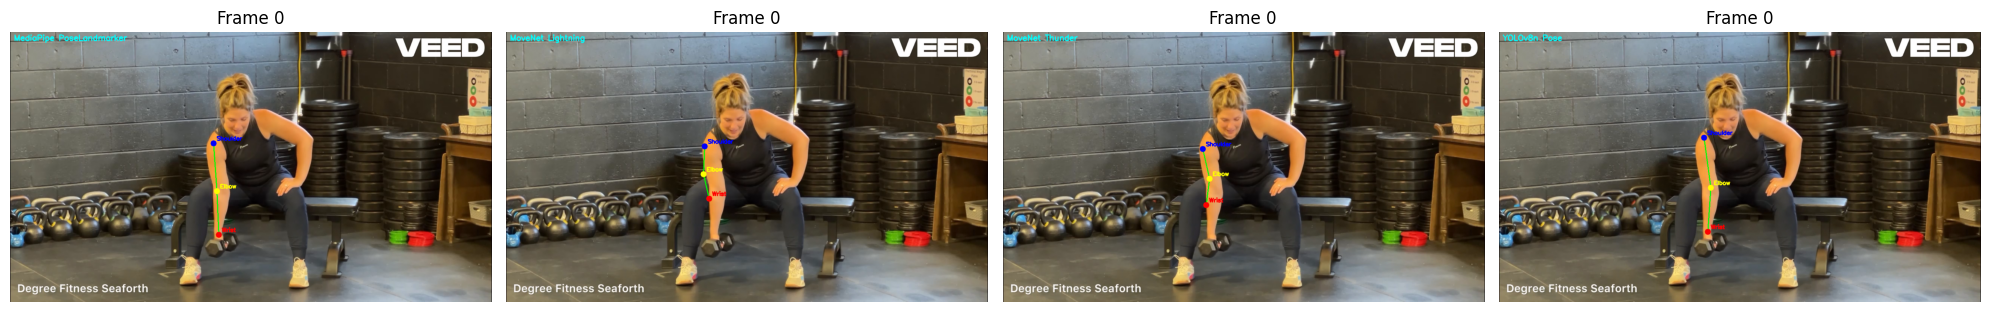

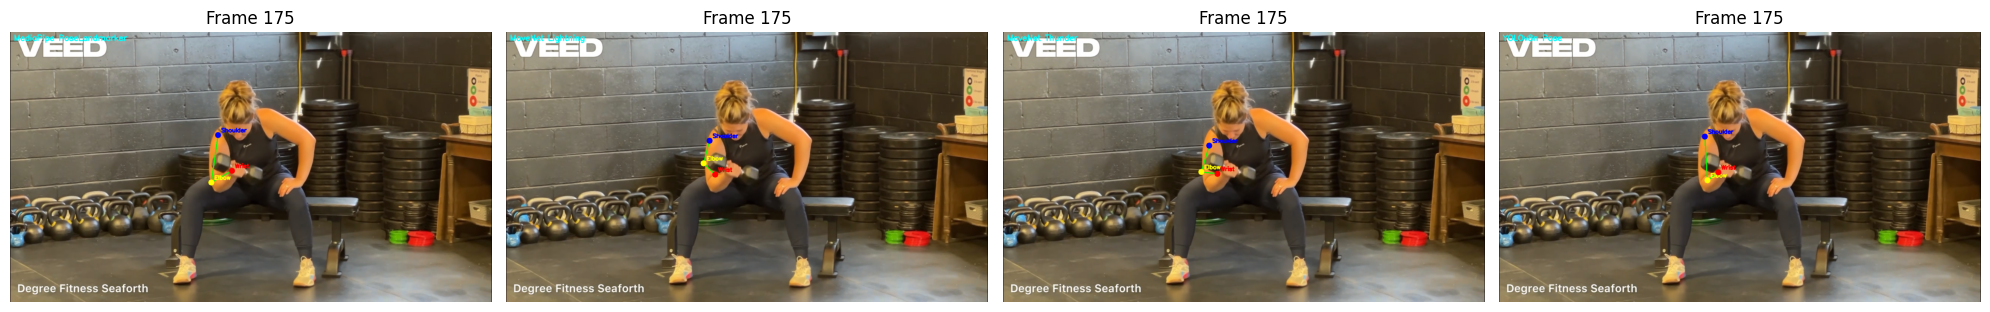

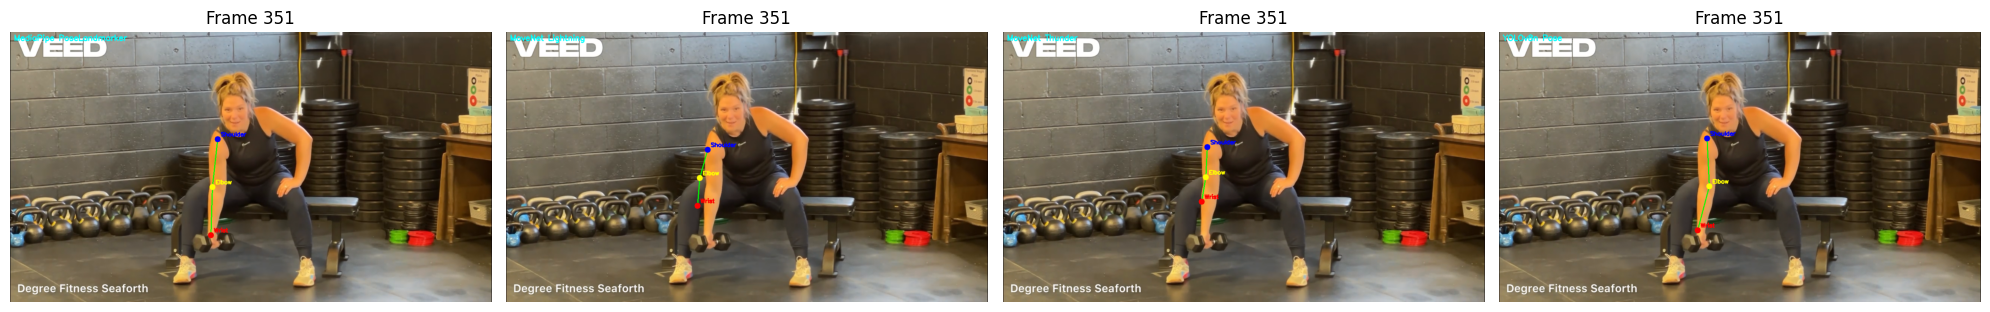

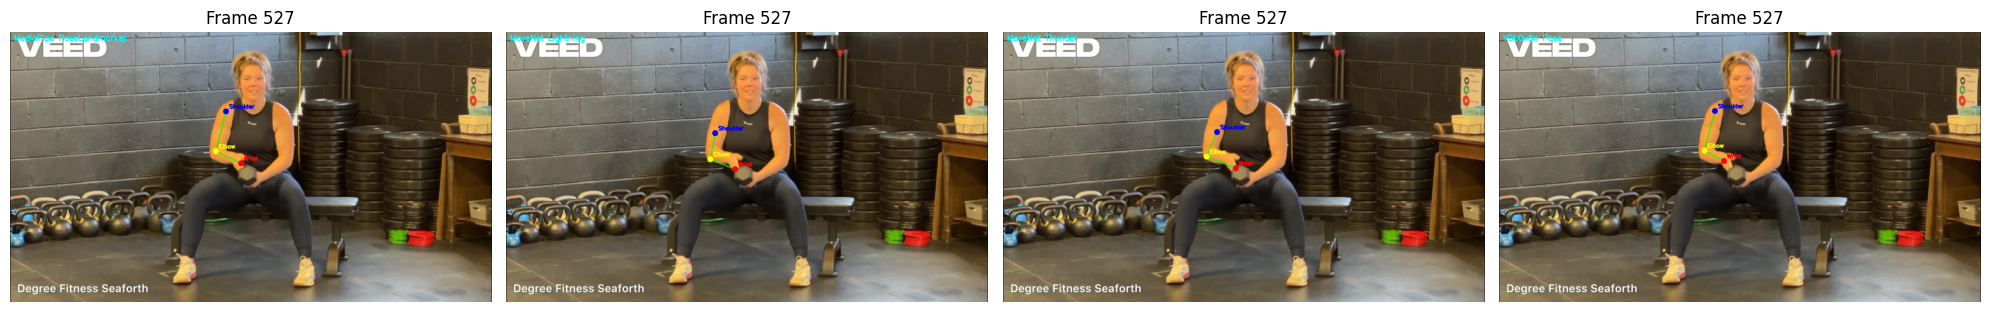

In [13]:
def dessiner_points_articulations(frame_bgr, epaule, coude, poignet, nom_modele=""):
    """Annote une frame avec les trois articulations et les segments qui les relient."""
    image = frame_bgr.copy()

    if epaule is not None and coude is not None and not (np.any(np.isnan(epaule)) or np.any(np.isnan(coude))):
        cv2.line(image, (int(epaule[0]), int(epaule[1])), (int(coude[0]), int(coude[1])), (0, 255, 0), 2)

    if coude is not None and poignet is not None and not (np.any(np.isnan(coude)) or np.any(np.isnan(poignet))):
        cv2.line(image, (int(coude[0]), int(coude[1])), (int(poignet[0]), int(poignet[1])), (0, 255, 0), 2)

    if epaule is not None and not np.any(np.isnan(epaule)):
        cv2.circle(image, (int(epaule[0]), int(epaule[1])), 8, (255, 0, 0), -1)
        cv2.putText(image, "Shoulder", (int(epaule[0]) + 8, int(epaule[1]) - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    if coude is not None and not np.any(np.isnan(coude)):
        cv2.circle(image, (int(coude[0]), int(coude[1])), 8, (0, 255, 255), -1)
        cv2.putText(image, "Elbow", (int(coude[0]) + 8, int(coude[1]) - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

    if poignet is not None and not np.any(np.isnan(poignet)):
        cv2.circle(image, (int(poignet[0]), int(poignet[1])), 8, (0, 0, 255), -1)
        cv2.putText(image, "Wrist", (int(poignet[0]) + 8, int(poignet[1]) - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    cv2.putText(image, nom_modele, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    return image


def afficher_comparaison_points_modeles(frames_bgr, resultats, nb_frames=4):
    """Affiche cote a cote les articulations detectees par chaque modele sur plusieurs frames."""
    if len(frames_bgr) == 0 or len(resultats) == 0:
        return

    indices = np.linspace(0, len(frames_bgr) - 1, min(nb_frames, len(frames_bgr))).astype(int)

    for idx in indices:
        fig, axes = plt.subplots(1, len(resultats), figsize=(5 * len(resultats), 5))
        if len(resultats) == 1:
            axes = [axes]

        for ax, r in zip(axes, resultats):
            epaule = r.points_epaule[idx] if idx < len(r.points_epaule) else None
            coude = r.points_coude[idx] if idx < len(r.points_coude) else None
            poignet = r.points_poignet[idx] if idx < len(r.points_poignet) else None

            image_annotee = dessiner_points_articulations(
                frames_bgr[idx], epaule, coude, poignet, nom_modele=r.nom_modele
            )

            ax.imshow(cv2.cvtColor(image_annotee, cv2.COLOR_BGR2RGB))
            ax.set_title(f"Frame {idx}")
            ax.axis("off")

        plt.tight_layout()
        plt.show()


afficher_comparaison_points_modeles(frames_bgr, resultats, nb_frames=4)

## 13. Graphiques par modele

Pour chaque modele, on affiche l'evolution de l'angle du coude au fil des frames, avec les seuils de detection et les repetitions comptees (points rouges).

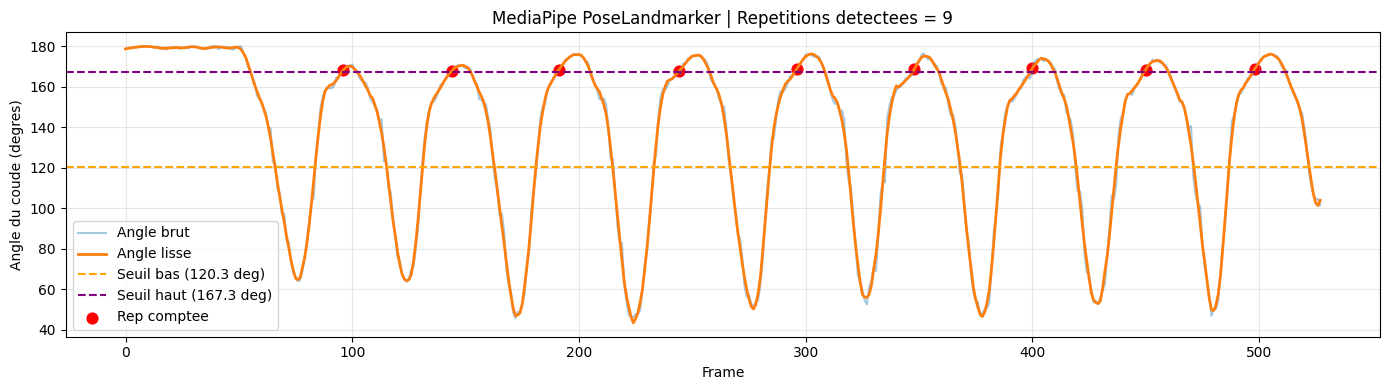

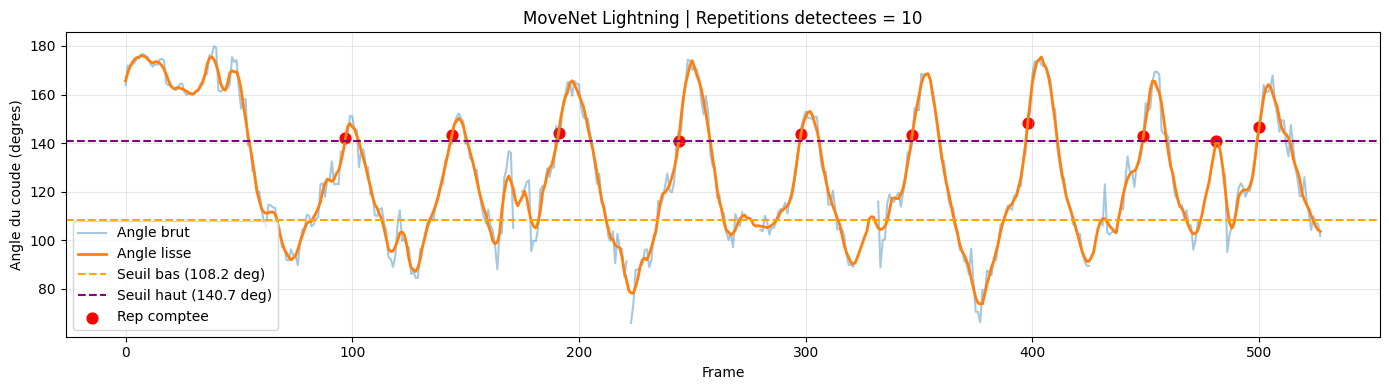

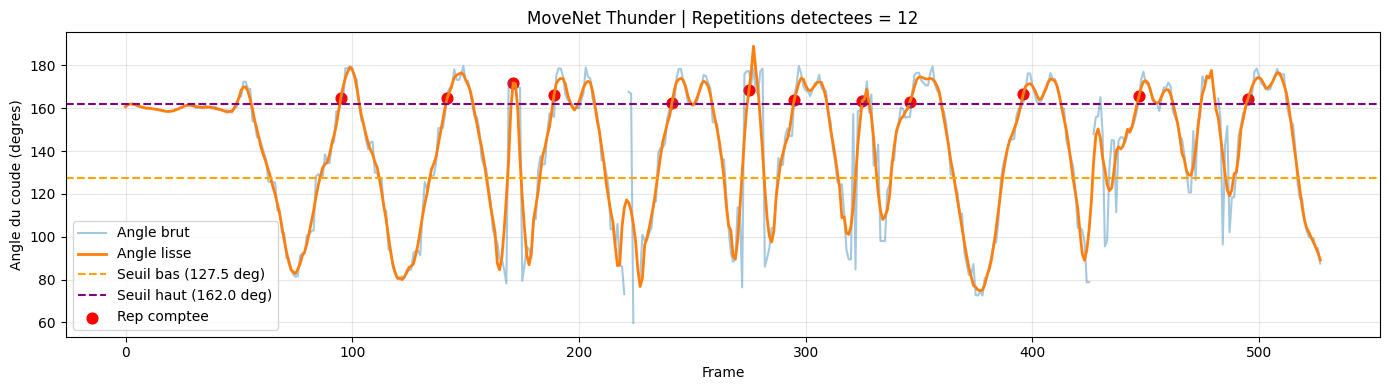

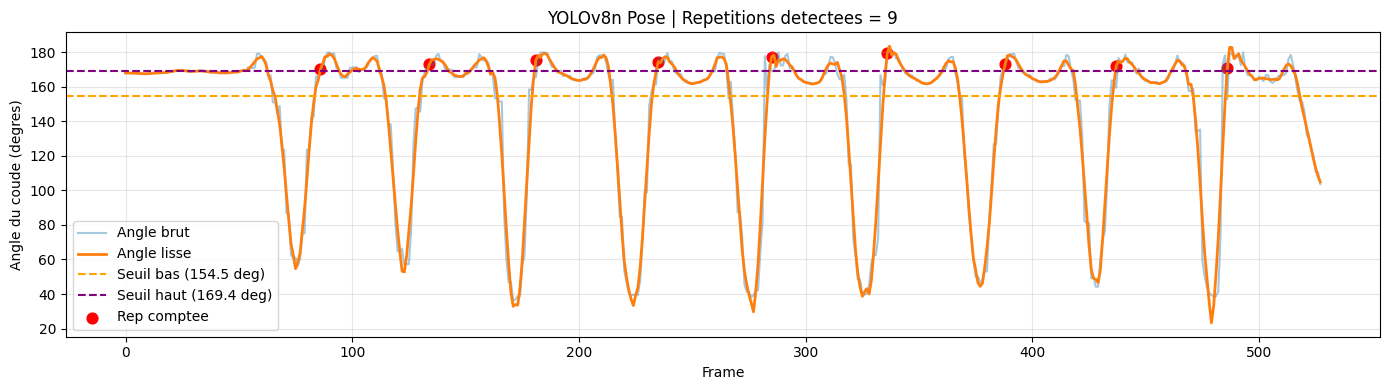

In [14]:
for r in resultats:
    x = np.arange(len(r.angle_brut))

    plt.figure(figsize=(14, 4))
    plt.plot(x, r.angle_brut, alpha=0.4, label="Angle brut")
    plt.plot(x, r.angle_lisse, linewidth=2, label="Angle lisse")

    if np.isfinite(r.seuil_bas):
        plt.axhline(r.seuil_bas, color="orange", linestyle="--", linewidth=1.5,
                    label=f"Seuil bas ({r.seuil_bas:.1f} deg)")

    if np.isfinite(r.seuil_haut):
        plt.axhline(r.seuil_haut, color="purple", linestyle="--", linewidth=1.5,
                    label=f"Seuil haut ({r.seuil_haut:.1f} deg)")

    if len(r.evenements_reps):
        # Points rouges = instants ou une repetition est comptee
        plt.scatter(
            r.evenements_reps,
            r.angle_lisse[r.evenements_reps],
            color="red",
            marker="o",
            s=60,
            label="Rep comptee"
        )

    plt.title(f"{r.nom_modele} | Repetitions detectees = {r.nb_reps}")
    plt.xlabel("Frame")
    plt.ylabel("Angle du coude (degres)")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

## 14. Comparaison entre modeles

Ce graphique superpose les courbes d'angle lisse de tous les modeles. On peut ainsi voir a quel point ils sont coherents entre eux.

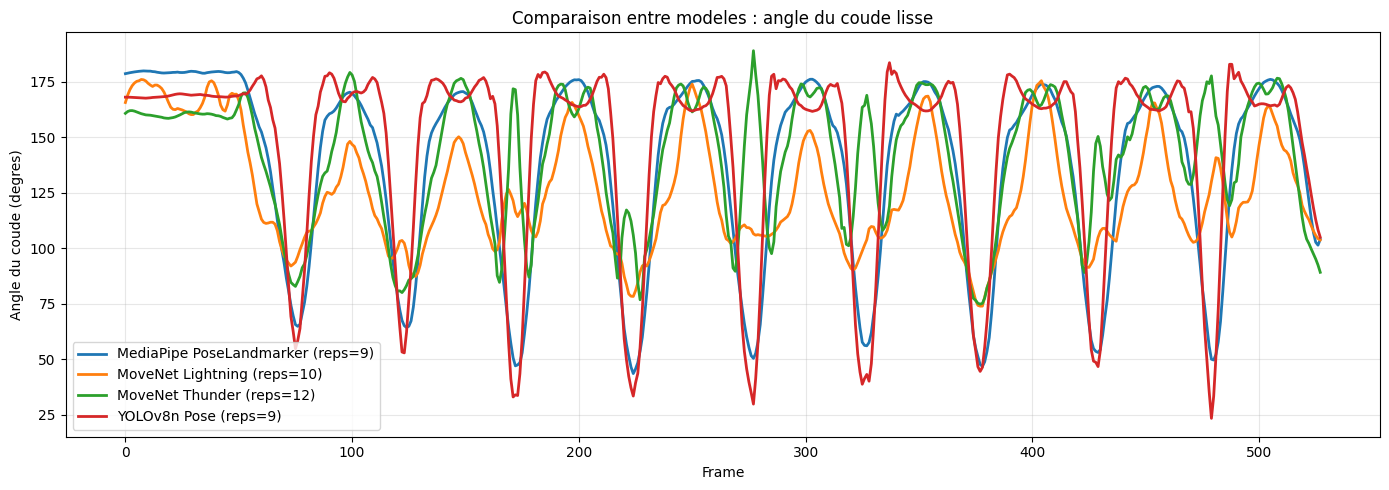

In [15]:
plt.figure(figsize=(14, 5))

for r in resultats:
    plt.plot(r.angle_lisse, label=f"{r.nom_modele} (reps={r.nb_reps})", linewidth=2)

plt.title("Comparaison entre modeles : angle du coude lisse")
plt.xlabel("Frame")
plt.ylabel("Angle du coude (degres)")
plt.grid(True, alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## 15. Tableau de benchmark

Ce tableau recapitule les performances de chaque modele. Les colonnes principales sont :

| Colonne | Signification |
|---|---|
| Reps detectees | Nombre de repetitions comptees par le modele |
| Erreur reps | Difference avec le nombre reel |
| Ratio detection valide | Part des frames ou une pose a ete detectee |
| FPS estime | Vitesse de traitement |
| Metrique stabilite | Regularite du signal (plus petit = plus stable) |
| Confiance moyenne | Niveau de certitude moyen du modele sur ses detections |

In [16]:
lignes = []

for r in resultats:
    erreur_reps = int(r.nb_reps - NB_REPS_REEL)

    lignes.append({
        "Modele": r.nom_modele,
        "Reps detectees": int(r.nb_reps),
        "Reps reelles": int(NB_REPS_REEL),
        "Erreur reps": erreur_reps,
        "Erreur absolue reps": abs(erreur_reps),
        "Ratio detection valide": r.ratio_detection_valide,
        "FPS estime": r.fps_estime,
        "Temps moyen par frame (ms)": r.temps_moyen_frame_ms,
        "Metrique stabilite": r.stabilite,
        "Confiance moyenne": r.confiance_moyenne,
        "Angle min": r.angle_min,
        "Angle max": r.angle_max,
        "Angle moyen": r.angle_moyen,
        "Seuil bas": r.seuil_bas,
        "Seuil haut": r.seuil_haut,
        "Video overlay": r.chemin_overlay if r.chemin_overlay else "(non sauvegardee)",
    })

# Tri par erreur absolue puis erreur signee
benchmark_df = pd.DataFrame(lignes)
benchmark_df = benchmark_df.sort_values(by=["Erreur absolue reps", "Erreur reps"]).reset_index(drop=True)

print("Tableau de benchmark final :")
display(benchmark_df)

chemin_csv = os.path.join(DOSSIER_SORTIE, "benchmark_modeles.csv")
benchmark_df.to_csv(chemin_csv, index=False)
print("Fichier CSV sauvegarde :", chemin_csv)

Tableau de benchmark final :


,Modele,Reps detectees,Reps reelles,Erreur reps,Erreur absolue reps,Ratio detection valide,FPS estime,Temps moyen par frame (ms),Metrique stabilite,Confiance moyenne,Angle min,Angle max,Angle moyen,Seuil bas,Seuil haut,Video overlay
0,MediaPipe PoseLandmarker,9,9,0,0,1.000000,39.810296,25.119130,5.837325,0.985264,43.450222,179.889632,136.818591,120.324675,167.345207,(non sauvegardee)
1,YOLOv8n Pose,9,9,0,0,1.000000,79.369242,12.599339,8.668256,0.974112,23.276129,183.589846,145.832249,154.512953,169.399344,(non sauvegardee)
2,MoveNet Lightning,10,9,1,1,0.933712,33.371209,29.965951,3.647320,0.568096,73.847222,176.028019,125.978743,108.188827,140.714714,(non sauvegardee)
3,MoveNet Thunder,12,9,3,3,0.984848,39.427708,25.362875,6.094325,0.634064,74.773539,188.990516,141.367472,127.465118,161.962149,(non sauvegardee)


Fichier CSV sauvegarde : benchmark_outputs/benchmark_modeles.csv


## 16. Graphiques de comparaison

Trois graphiques en barres pour comparer rapidement les modeles sur les criteres principaux.

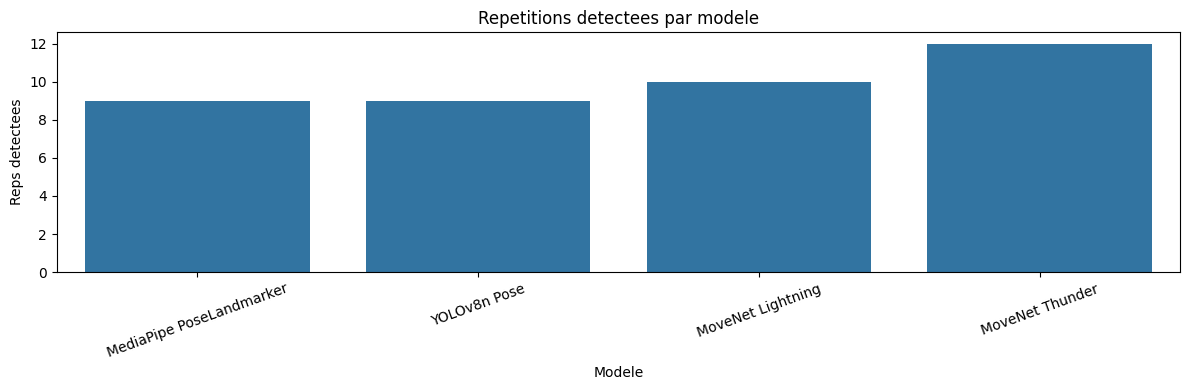

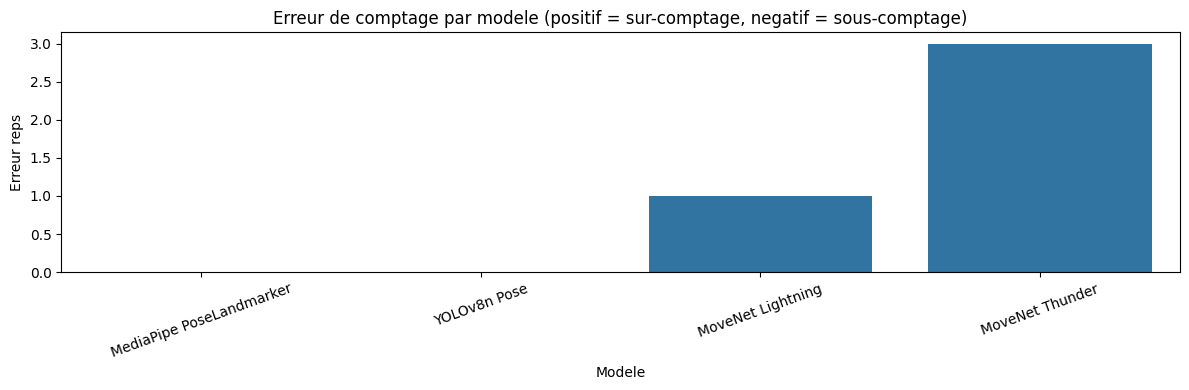

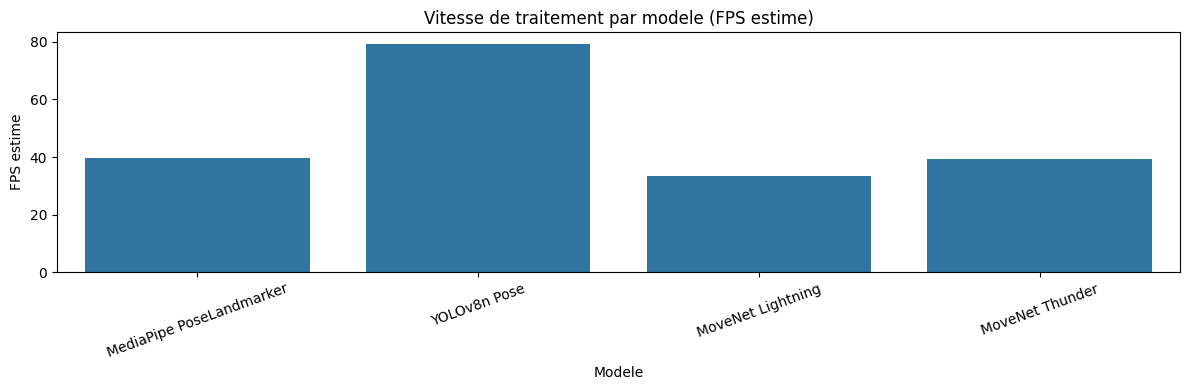

In [17]:
plt.figure(figsize=(12, 4))
sns.barplot(data=benchmark_df, x="Modele", y="Reps detectees")
plt.title("Repetitions detectees par modele")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.barplot(data=benchmark_df, x="Modele", y="Erreur reps")
plt.title("Erreur de comptage par modele (positif = sur-comptage, negatif = sous-comptage)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.barplot(data=benchmark_df, x="Modele", y="FPS estime")
plt.title("Vitesse de traitement par modele (FPS estime)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()